## Imports and setup

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Basic imports
import pandas as pd
import numpy as np

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import recall_score, f1_score, roc_auc_score, fbeta_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import seaborn as sns

# confusion matrix specific
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Set random seed
RANDOM_STATE = 42


In [5]:
filepath = '/content/drive/MyDrive/data/enrollment/data/training_clean.csv'

df = pd.read_csv(filepath)
df.drop('Unnamed: 0', axis=1,inplace=True)

In [6]:
X = df.drop(columns=['Enrolled2'])
y = df['Enrolled2']

# First split into train+val and test (80/20)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Now split train+val into train and val (60/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval)  # 0.25 * 0.8 = 0.2


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# All features

## Regression Forest

In [59]:
reg_all = RandomForestRegressor(random_state=RANDOM_STATE, min_samples_leaf=10,n_estimators=100,max_depth=10)
reg_all.fit(X_train, y_train)
y_val_pred_reg_all = reg_all.predict(X_val)

roc_auc_all_reg = roc_auc_score(y_val, y_val_pred_reg_all)

print("Regressor (All Features):")
print(f"ROC AUC: {roc_auc_all_reg:.4f}")


Regressor (All Features):
ROC AUC: 0.7809


## Classifier Forest

In [60]:
clf_all = RandomForestClassifier(random_state=RANDOM_STATE, min_samples_leaf=5,n_estimators=100,min_samples_split=2,class_weight='balanced',max_depth=None)
clf_all.fit(X_train, y_train)
y_val_pred_clf_all = clf_all.predict(X_val)

# Evaluation
recall_all_clf = recall_score(y_val, y_val_pred_clf_all)
f1_all_clf = f1_score(y_val, y_val_pred_clf_all)
roc_auc_all_clf = roc_auc_score(y_val, clf_all.predict_proba(X_val)[:, 1])

print("Classifier (All Features):")
print(f"Recall: {recall_all_clf:.4f}")
print(f"F1 Score: {f1_all_clf:.4f}")
print(f"ROC AUC: {roc_auc_all_clf:.4f}")


Classifier (All Features):
Recall: 0.5913
F1 Score: 0.5972
ROC AUC: 0.7910


## Logistic Regression

In [9]:

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

# Predict probabilities
y_val_proba_logreg = logreg.predict_proba(X_val_scaled)[:, 1]

# Choose threshold that maximizes recall
thresholds = np.linspace(0.0, 1.0, 101)

best_thresh = 0.5
best_f2 = 0

for t in thresholds:
    y_pred = (y_val_proba_logreg >= t).astype(int)
    f2 = fbeta_score(y_val, y_pred, beta=2)

    if f2 > best_f2:
        best_f2 = f2
        best_thresh = t

print(f"Best threshold for F2-score: {best_thresh:.2f}, F2: {best_f2:.4f}")

y_test_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_test_proba_logreg >= best_thresh).astype(int)
test_f2 = fbeta_score(y_test, y_pred, beta=2)
test_recall = recall_score(y_test, y_pred)
print(f"At threshold {best_thresh:.2f}, test F2: {test_f2:.4f}, test recall: {test_recall:.4f}")

Best threshold for F2-score: 0.27, F2: 0.6678
At threshold 0.27, test F2: 0.6630, test recall: 0.9087


## Neural Network

In [71]:

# Build a simple FNN
nn_model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # outputs probability
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(name='recall')]
)

# Train
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6924 - recall: 0.4153 - val_loss: 0.5098 - val_recall: 0.1071
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5082 - recall: 0.2672 - val_loss: 0.4890 - val_recall: 0.2103
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4616 - recall: 0.3499 - val_loss: 0.4835 - val_recall: 0.2421
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4639 - recall: 0.4056 - val_loss: 0.4844 - val_recall: 0.2540
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4472 - recall: 0.4521 - val_loss: 0.4768 - val_recall: 0.3056
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4421 - recall: 0.4882 - val_loss: 0.4775 - val_recall: 0.2897
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4396 - recall: 0.4577 - val_loss: 0.4787 - val_recall: 0.3056
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4095 - recall: 0.4454 - val_loss: 0.4701 - val_recall: 0.3452
Epoch 9/30
93/93 ━━━━━━━

# Top k features

In [62]:
# Use mutual information to select top k features
k = 15  # You can experiment with different values
selector = SelectKBest(score_func=mutual_info_classif, k=k)
selector.fit(X_train, y_train)

# Get mask and reduced datasets
mask = selector.get_support()
X_train_sel = X_train.loc[:, mask]
X_val_sel = X_val.loc[:, mask]
X_test_sel = X_test.loc[:, mask]

selected_feature_names = X_train_sel.columns.tolist()
print(f"Selected Top {k} Features:\n", selected_feature_names)


Selected Top 15 Features:
 ['Female', 'New Student', 'Double Major', 'highschool_Public HS-Outside CA', 'highschool_SDA HS-PU Conf Constituent', 'CA Resident', 'RELIGION_SDA', 'NETHN_0.0', 'NETHN_2.0', 'RACE_B', 'RACE_A', 'RACE_unknown', 'admit_deg_code_0.0', 'admit_deg_code_1.0', 'admit_deg_code_43.0']


## Regression forest

In [63]:
reg_sel = RandomForestRegressor(random_state=RANDOM_STATE, min_samples_leaf=5,n_estimators=100,max_depth=10)
reg_sel.fit(X_train_sel, y_train)
y_val_pred_reg_sel = reg_sel.predict(X_val_sel)

roc_auc_sel_reg = roc_auc_score(y_val, y_val_pred_reg_sel)

print("Regressor (Selected Features):")
print(f"ROC AUC: {roc_auc_sel_reg:.4f}")


Regressor (Selected Features):
ROC AUC: 0.7731


## Classifier forest

In [64]:
clf_sel = RandomForestClassifier(random_state=RANDOM_STATE, min_samples_leaf=5,n_estimators=100,min_samples_split=2,class_weight='balanced',max_depth=None)
clf_sel.fit(X_train_sel, y_train)
y_val_pred_clf_sel = clf_sel.predict(X_val_sel)

recall_sel_clf = recall_score(y_val, y_val_pred_clf_sel)
f1_sel_clf = f1_score(y_val, y_val_pred_clf_sel)
roc_auc_sel_clf = roc_auc_score(y_val, clf_sel.predict_proba(X_val_sel)[:, 1])

print("Classifier (Selected Features):")
print(f"Recall: {recall_sel_clf:.4f}")
print(f"F1 Score: {f1_sel_clf:.4f}")
print(f"ROC AUC: {roc_auc_sel_clf:.4f}")


Classifier (Selected Features):
Recall: 0.5595
F1 Score: 0.5651
ROC AUC: 0.7643


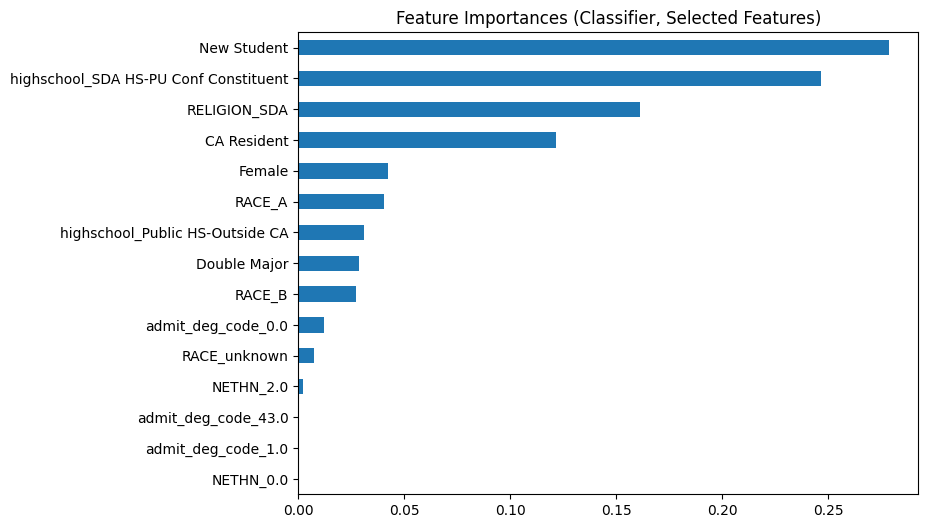

In [65]:
importances = pd.Series(clf_sel.feature_importances_, index=selected_feature_names)
importances.sort_values().plot(kind='barh', title="Feature Importances (Classifier, Selected Features)", figsize=(8, 6))
plt.show()


# Comparison

In [76]:
threshold = 0.5

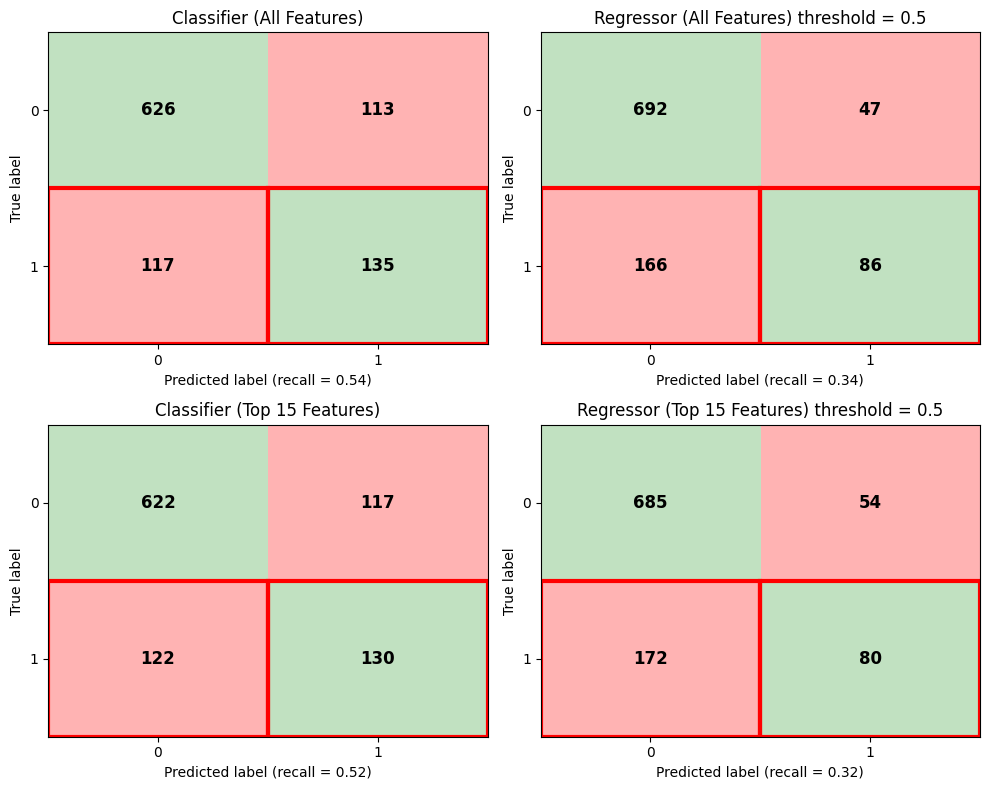

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

cms = []

y_test_pred_clf_all = clf_all.predict(X_test)
cms.append(confusion_matrix(y_test, y_test_pred_clf_all))
#disp1 = ConfusionMatrixDisplay(confusion_matrix=cms[0])
#disp1.plot(ax=axes[0], values_format='d')
axes[0].set_title("Classifier (All Features)")


y_test_pred_reg_all_proba = reg_all.predict(X_test)
y_test_pred_reg_all = (y_test_pred_reg_all_proba >= threshold).astype(int)
cms.append(confusion_matrix(y_test, y_test_pred_reg_all))
#disp2 = ConfusionMatrixDisplay(confusion_matrix=cms[1])
#disp2.plot(ax=axes[1], values_format='d')
axes[1].set_title(f"Regressor (All Features) threshold = {threshold}")



y_test_pred_clf_sel = clf_sel.predict(X_test_sel)
cms.append(confusion_matrix(y_test, y_test_pred_clf_sel))
#disp3 = ConfusionMatrixDisplay(confusion_matrix=cms[2])
#disp3.plot(ax=axes[2], values_format='d')
axes[2].set_title("Classifier (Top 15 Features)")


y_test_pred_reg_sel_proba = reg_sel.predict(X_test_sel)
y_test_pred_reg_sel = (y_test_pred_reg_sel_proba >= threshold).astype(int)
cms.append(confusion_matrix(y_test, y_test_pred_reg_sel))
#disp4 = ConfusionMatrixDisplay(confusion_matrix=cms[3])
#disp4.plot(ax=axes[3], values_format='d')
axes[3].set_title(f"Regressor (Top 15 Features) threshold = {threshold}")


# Define pastel colors
pastel_green = '#c1e1c1'  # Light green
pastel_red = '#ffb3b3'    # Light red

# Loop through your four confusion matrices
for i in range(4):
    # Assuming you have these matrices - replace with your actual values
    cm = cms[i]

    # Create a custom colormap matrix where:
    # - 1 represents pastel green (TP and TN)
    # - 0 represents pastel red (FP and FN)
    color_matrix = np.ones_like(cm, dtype=float)

    # Set false positive (top right) to red
    if cm.shape == (2, 2):
        color_matrix[0, 1] = 0
        # Set false negative (bottom left) to red
        color_matrix[1, 0] = 0
    else:
        # diagonal is green, off-diagonal is red
        # for big confusion matrices
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                if row != col:
                    color_matrix[row, col] = 0

    # Create custom colormap with just our two colors
    custom_cmap = ListedColormap([pastel_red, pastel_green])

    # Plot the confusion matrix
    im = axes[i].imshow(color_matrix, cmap=custom_cmap, aspect='auto')

    # Recall
    sensitivity = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0

    # Add text annotations with the actual values
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            axes[i].text(col, row, str(cm[row, col]),
                        ha="center", va="center",
                        color="black", fontsize=12, fontweight='bold')

    for cell in [(1, 0), (1, 1)]:
        row, col = cell
        # Add the highlight 'recall' border
        if row < cm.shape[0] and col < cm.shape[1]:
            rect = patches.Rectangle(
                (col - 0.5, row - 0.5),
                1, 1,
                linewidth=3,
                edgecolor='red',
                facecolor='none',
                zorder=2  # Make sure it's on top
            )
            axes[i].add_patch(rect)

    # Add labels, title, and ticks
    axes[i].set_xlabel(f'Predicted label (recall = {sensitivity:.2f})')
    axes[i].set_ylabel('True label')

    # Set tick positions and labels
    classes = [f'Class {j}' for j in range(cm.shape[0])]
    axes[i].set_xticks(np.arange(len(classes)))
    axes[i].set_yticks(np.arange(len(classes)))


plt.tight_layout()
plt.show()

## Evaluating Logistic Regression

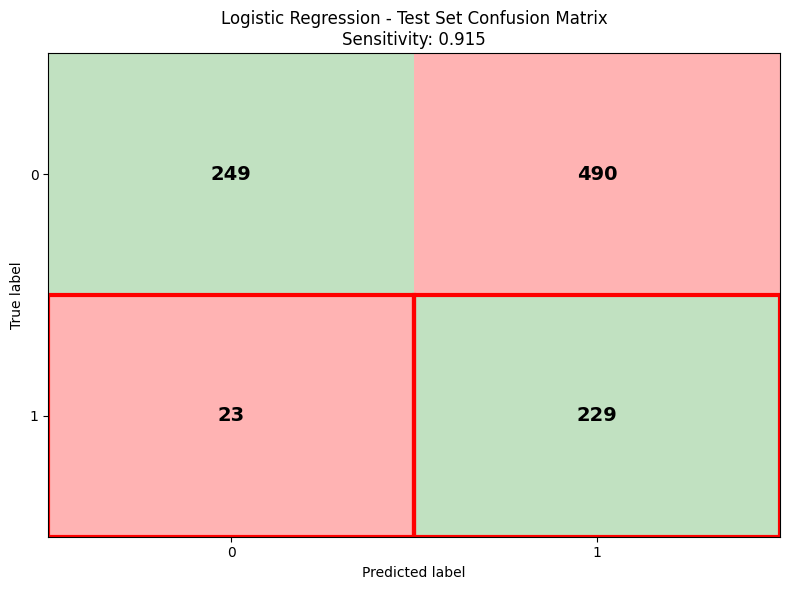

In [18]:
y_test_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
y_test_pred_logreg = (y_test_proba_logreg >= best_thresh).astype(int)

cm_logreg = confusion_matrix(y_test, y_test_pred_logreg)

fig, ax = plt.subplots(figsize=(8, 6))


# Create a custom colormap matrix where:
# - 1 represents pastel green (TP and TN)
# - 0 represents pastel red (FP and FN)
pastel_green = '#c1e1c1'
pastel_red = '#ffb3b3'
color_matrix = np.ones_like(cm_logreg, dtype=float)
color_matrix[0, 1] = 0
color_matrix[1, 0] = 0

custom_cmap = ListedColormap([pastel_red, pastel_green])


# Plot the confusion matrix
im = ax.imshow(color_matrix, cmap=custom_cmap, aspect='auto')

for row in range(cm_logreg.shape[0]):
    for col in range(cm_logreg.shape[1]):
        ax.text(col, row, str(cm_logreg[row, col]),
                ha="center", va="center",
                color="black", fontsize=14, fontweight='bold')

sensitivity = cm_logreg[0, 0] / (cm_logreg[0, 0] + cm_logreg[1, 0]) if (cm_logreg[0, 0] + cm_logreg[1, 0]) > 0 else 0

# Add labels and title
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f"Logistic Regression - Test Set Confusion Matrix\nSensitivity: {sensitivity:.3f}")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

# Highlight specific cells [1,0] and [1,1]
for cell in [(1, 0), (1, 1)]:
    row, col = cell
    rect = plt.Rectangle(
        (col - 0.5, row - 0.5),
        1, 1,
        linewidth=3,
        edgecolor='red',
        facecolor='none',
        zorder=2  # Make sure it's on top
    )
    ax.add_patch(rect)

plt.tight_layout()
plt.show()
